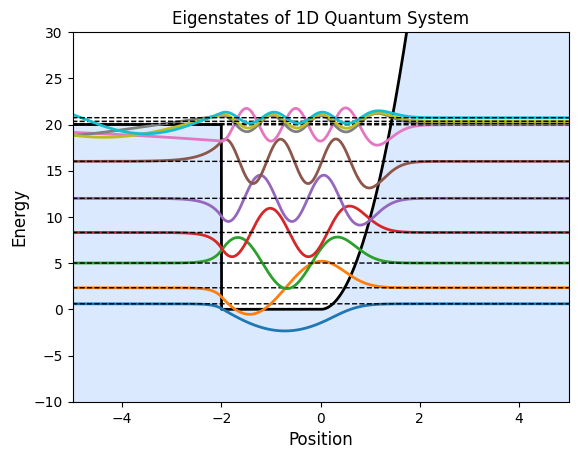

Text(0.5, 1.0, 'Eigenstates of 1D Quantum System')

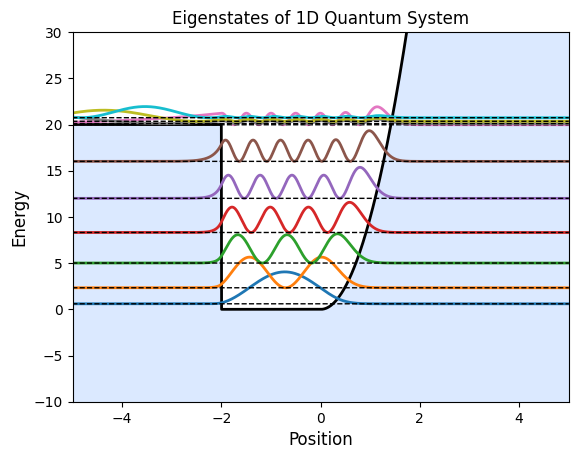

In [1]:
# Solve Schrödinger equation for every 1D system using Finite Difference Method and Eigenvalue Decomposition
import numpy as np
import matplotlib.pyplot as plt

# plt.style.use('classic')
# plt.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
# plt.rc('text', usetex=True) 

# Constant
hbar = 1.0  # Reduced Planck's constant
m = 1.0    # Particle mass

dx = 0.005
x_min = -10
x_max = 10
Nx = int((x_max - x_min) / dx) 
x = np.linspace(x_min, x_max, Nx + 1)

# Semi-harmonic oscillator potential
V = np.zeros(Nx-1)
for i in range(Nx-1):
    V[i] = 20 if x[i]<-2 else 0  
    V[i] = 0 if x[i]>-2 and x[i]<1 else V[i]
    V[i] = 10*x[i]**2 if x[i]>0 else V[i]

# Halmiltonian matrix
lamb = hbar**2/(2*m*dx**2)
H =lamb*(np.diag(2*np.ones(Nx-1) + V/lamb,0) + (-1)*np.diag(np.ones(Nx-2),1) + (-1)*np.diag(np.ones(Nx-2),-1))
E,psi = np.linalg.eigh(H)  # Eigenvalue decomposition
psi = psi.T  

# Plot Eigenstates
N = 10  # Number of eigenstates to plot
plt.plot(x[1:-1], V, lw=2, label='V(x)', color='k')
plt.fill_between(x[1:-1], -10, V, color='#dbe9ff')
for i in range(N):
    plt.plot(x[1:-1], E[i] + 50*np.real(psi[i,:]), lw=2, label=f'n={i+1}, E={E[i]:.2f}')
    plt.plot(x[1:-1], np.full_like(x[1:-1], E[i]), lw=1, ls='--', color='k')
plt.xlim(-5,5)
plt.ylim(-10,30)
plt.xlabel('Position', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('Eigenstates of 1D Quantum System', fontsize=12)
# plt.legend()
# plt.savefig('eigenstate.eps', format='eps', bbox_inches='tight')
plt.show()

# Plot Probability Density of Eigenstates
plt.plot(x[1:-1], V, lw=2, label='V(x)', color='k')
plt.fill_between(x[1:-1], -10, V, color='#dbe9ff')
for i in range(N):
    plt.plot(x[1:-1], E[i] + 1000*np.abs(psi[i,:])**2, lw=2, label=f'n={i+1}, E={E[i]:.2f}')
    plt.plot(x[1:-1], np.full_like(x[1:-1], E[i]), lw=1, ls='--', color='k')
plt.xlim(-5,5)
plt.ylim(-10,30)
plt.xlabel('Position', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.title('Eigenstates of 1D Quantum System', fontsize=12)

Transmission Coefficient: 0.2357
Reflection Coefficient: 0.7643


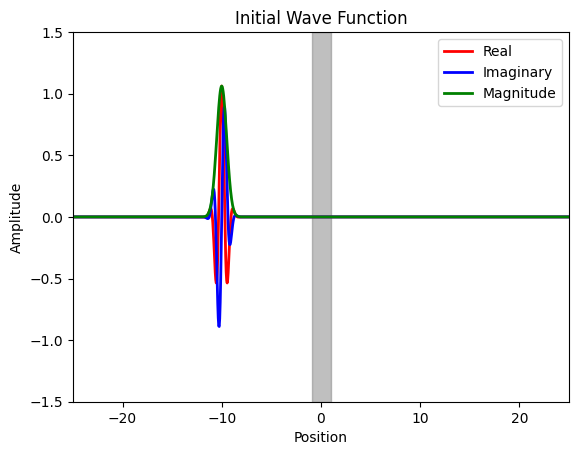

In [2]:
# Free quantum wave packet with potential barrier (Tunneling effect)

# Constant
hbar = 1.0  # Reduced Planck's constant
m = 1.0    # Particle mass

# Time steps
dt = 0.1
t_min = 0
t_max = 30
Nt = int((t_max - t_min) / dt) 
# Position step
dx = 0.05
x_min = -25
x_max = 25
Nx = int((x_max - x_min) / dx)
k = 5  # wave number -> classic with larger k
wavelength = 2 * np.pi / k
# w = hbar * k**2 / (2 * m)  # angular frequency
alpha = 0.5  # packet width
p = hbar * k  # momentum
KE = p**2/(2*m)  # Kinetic energy
x0 = -10  # Initial position

t = np.linspace(t_min, t_max, Nt + 1)
x = np.linspace(x_min, x_max, Nx + 1)

# Potential function
V = np.zeros(Nx-1)
ratio = 1
for i in range(Nx-1):
    if x[i]>-1 and x[i]<1:
        V[i] = ratio*KE

# Solve engine
def solve():
    # Initial wave function
    global t, x, dt, dx
    Psi0 = np.exp(1j*k*(x[1:-1]-x0)) * np.exp(-(x[1:-1]-x0)**2/(2*alpha**2))
    C0 = np.sqrt(np.sum(np.abs(Psi0[:])**2*dx))  # Normalization constant
    Psi0 = Psi0/C0
    
    # Halmiltonian matrix
    lamb = hbar**2/(2*m*dx**2)
    H =lamb*(np.diag(2*np.ones(Nx-1) + V/lamb,0) + (-1)*np.diag(np.ones(Nx-2),1) + (-1)*np.diag(np.ones(Nx-2),-1))
    E,psi = np.linalg.eigh(H)  # Eigenvalue decomposition
    psi = psi.T  

    c = np.zeros(Nx-1, dtype=complex)
    for n in range(Nx-1):
        c[n] = np.sum(np.conj(psi[n,:]) * Psi0[:]*dx)  # Expansion coefficients

    Psi = np.zeros((Nx-1, Nt), dtype=complex)
    for j in range(Nt):
        for n in range(Nx-1):
            Psi[:, j] += c[n] * psi[n, :] * np.exp(-1j * E[n] * t[j] / hbar)  # Time evolution
        C = np.sqrt(np.sum(np.abs(Psi[:, j])**2*dx))  # Normalization constant
        Psi[:, j] = Psi[:, j]/C
    return Psi  

Psi = solve() 

# Transmission and Reflection Coefficients
transmittion = np.sum(np.abs(Psi[int(Nx/2):, -1])**2*dx)
reflection = np.sum(np.abs(Psi[:int(Nx/2), -1])**2*dx)
print(f'Transmission Coefficient: {transmittion:.4f}')
print(f'Reflection Coefficient: {reflection:.4f}')

# Plot test
plt.plot(x[1:-1], np.real(Psi[:,0]), lw=2, color='red')
plt.plot(x[1:-1], np.imag(Psi[:,0]), lw=2, color='blue')
plt.plot(x[1:-1], np.abs(Psi[:,0]), lw=2, color='green')
plt.legend(['Real', 'Imaginary', 'Magnitude'])
plt.xlabel('Position')  
plt.ylabel('Amplitude')
plt.xlim(x_min, x_max)
plt.ylim(-1.5, 1.5)
plt.fill_between(x[1:-1], 0, 1, where=V > 0, color='gray', alpha=0.5, transform=plt.gca().get_xaxis_transform(), label='Potential')
plt.title('Initial Wave Function')
plt.show()

In [ ]:
from vpython import rate, gcurve, graph, canvas, color
scene = canvas()
g1 = graph(xtitle="x",ytitle="stuff", xmin=-25,xmax=25,ymin=0,ymax=1,width=500, height=250)
fP = gcurve(color=color.blue)
fV = gcurve(color=color.red, width = 2)

for i in range(len(V)):
    fV.plot(x[i],0.1*V[i])

for i in range(Nt):
    rate(10)
    fP.data = []
    for j in range(len(Psi[:, i])):        
        fP.plot(x[j+1], np.abs(Psi[j, i])**2)

<IPython.core.display.Javascript object>